# FInal Project

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

## Packages

In [ ]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)
library(forecast)
library(zoo)

## Loading Data

In [8]:
data <- load("data_project/26.RData")   # loads the .RData file into the environment
head(data)                               # shows the name(s) of objects stored in the file
asset_data <- get(data[1])              # retrieves the first object by name
head(asset_data)                        

[1] "amat"

                    ret         RV        RV_p        RV_n          RS       RK
2010-01-05  0.010600358 0.01537440 0.010802724 0.010939525  0.22027109 4.607369
2010-01-06 -0.002112787 0.01482381 0.011268814 0.009631161  0.58156996 3.443174
2010-01-07 -0.004239012 0.01455766 0.009431595 0.011089210 -0.53822008 4.062540
2010-01-08  0.006351798 0.01627584 0.012371915 0.010575383  0.02566745 4.681865
2010-01-11  0.041973644 0.02193678 0.013281618 0.017459120 -1.15919678 5.918139
2010-01-12 -0.006089911 0.02460140 0.014433799 0.019922207 -0.60888995 3.864707

"amat" is the ticker symbol for Applied Materials, Inc. (AMAT) - a large US semiconductor equipment company traded on NASDAQ. So our asset (#26) is the daily realized volatility data for Applied Materials stock, starting from January 2010.

## Exploratory analysis

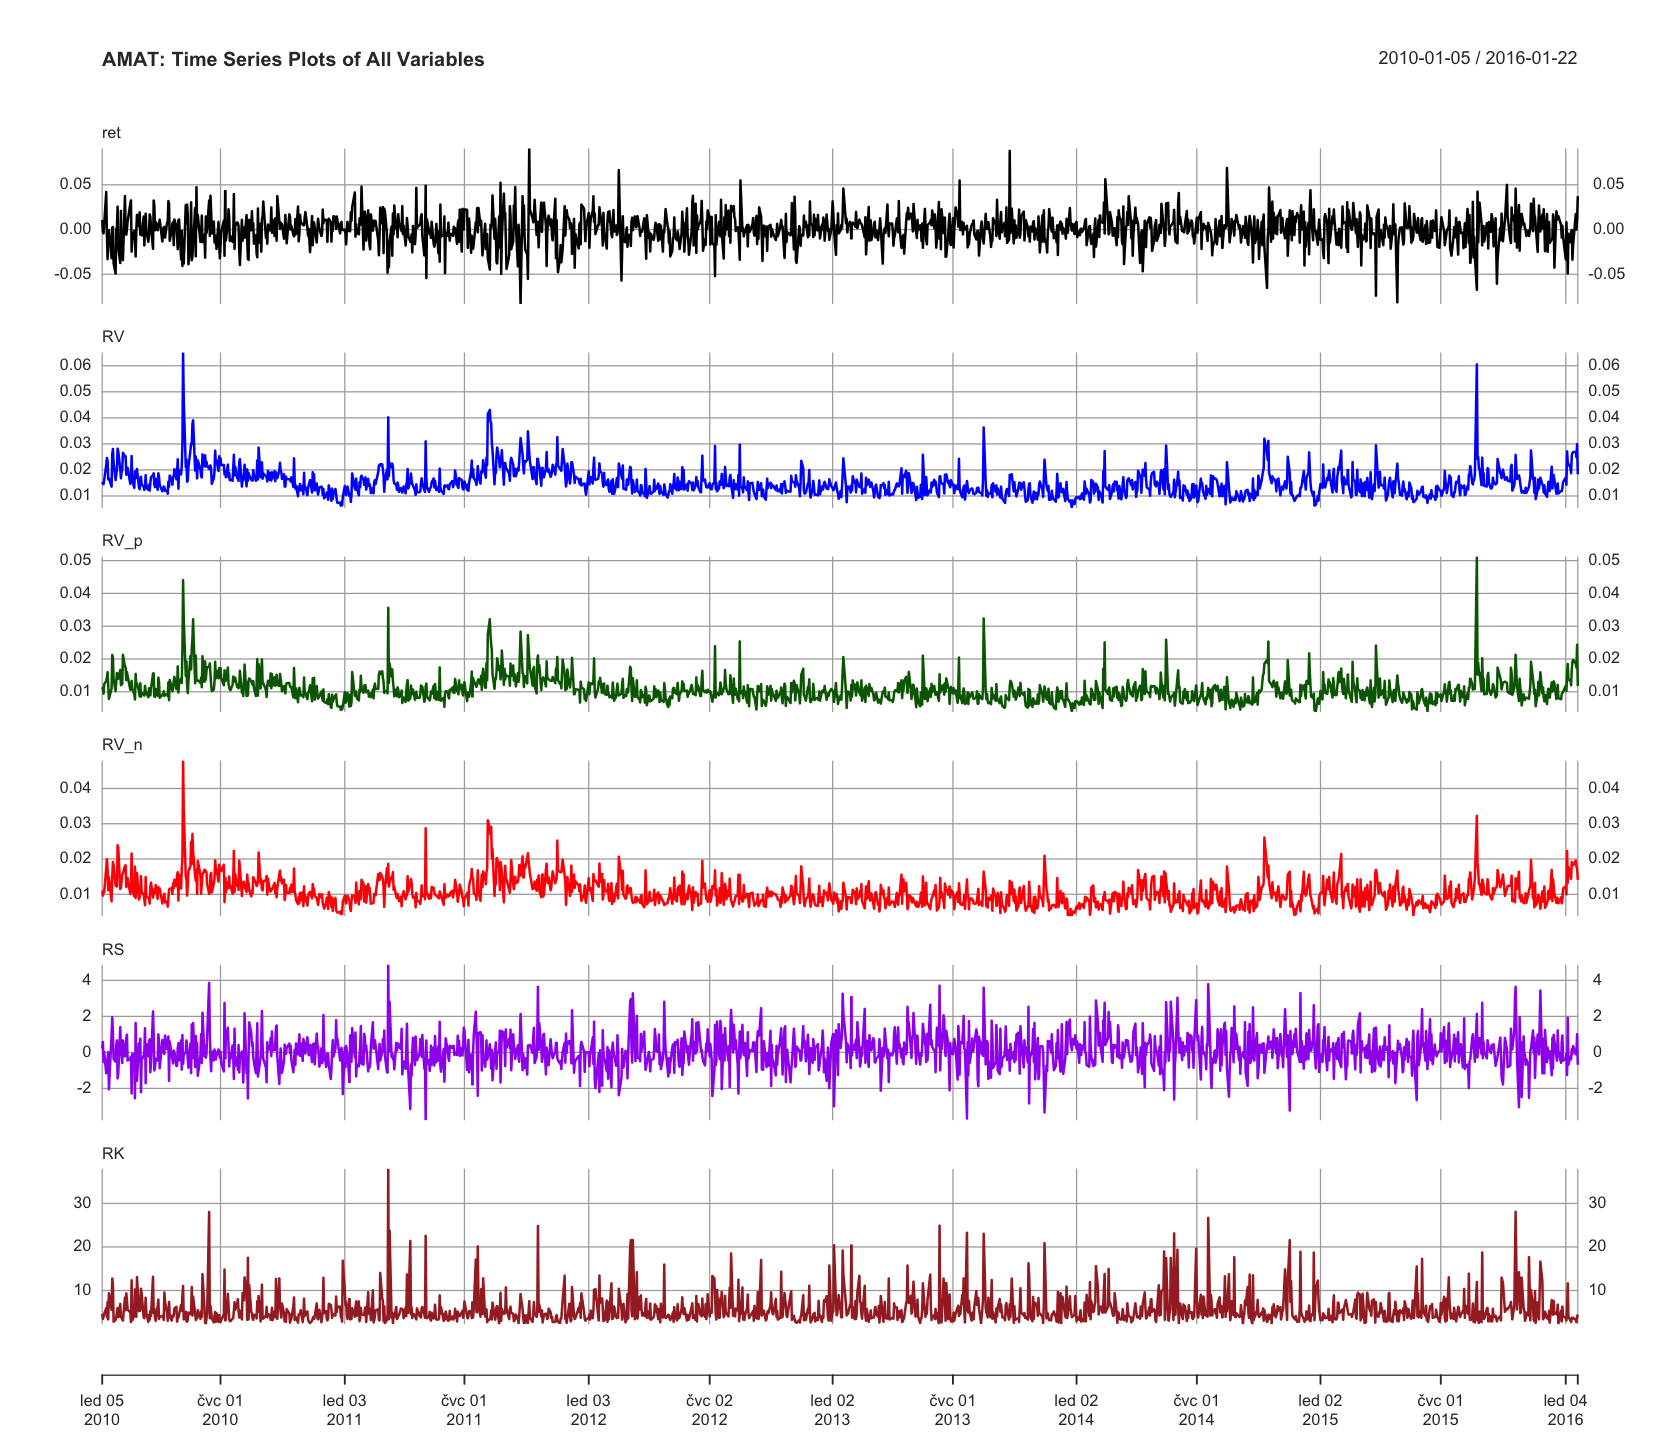

In [9]:
options(repr.plot.width = 14, repr.plot.height = 12)
plot.xts(asset_data, 
         multi.panel = TRUE, 
         yaxis.same = FALSE,
         col = c("black", "blue", "darkgreen", "red", "purple", "brown"),
         main = "AMAT: Time Series Plots of All Variables")

In [19]:
# descriptive statistics
summary(coredata(asset_data)) # view the summary of all columns except the index column

      ret                   RV                RV_p               RV_n         
 Min.   :-0.0831897   Min.   :0.005378   Min.   :0.003804   Min.   :0.003802  
 1st Qu.:-0.0096931   1st Qu.:0.011861   1st Qu.:0.008198   1st Qu.:0.007937  
 Median : 0.0008695   Median :0.014288   Median :0.010081   Median :0.009841  
 Mean   : 0.0002284   Mean   :0.015212   Mean   :0.010768   Mean   :0.010558  
 3rd Qu.: 0.0106051   3rd Qu.:0.017221   3rd Qu.:0.012362   3rd Qu.:0.012405  
 Max.   : 0.0906058   Max.   :0.065073   Max.   :0.051231   Max.   :0.047888  
       RS                 RK        
 Min.   :-3.76626   Min.   : 2.237  
 1st Qu.:-0.48534   1st Qu.: 3.636  
 Median : 0.07282   Median : 4.607  
 Mean   : 0.10153   Mean   : 5.713  
 3rd Qu.: 0.62721   3rd Qu.: 6.383  
 Max.   : 4.86950   Max.   :37.962  

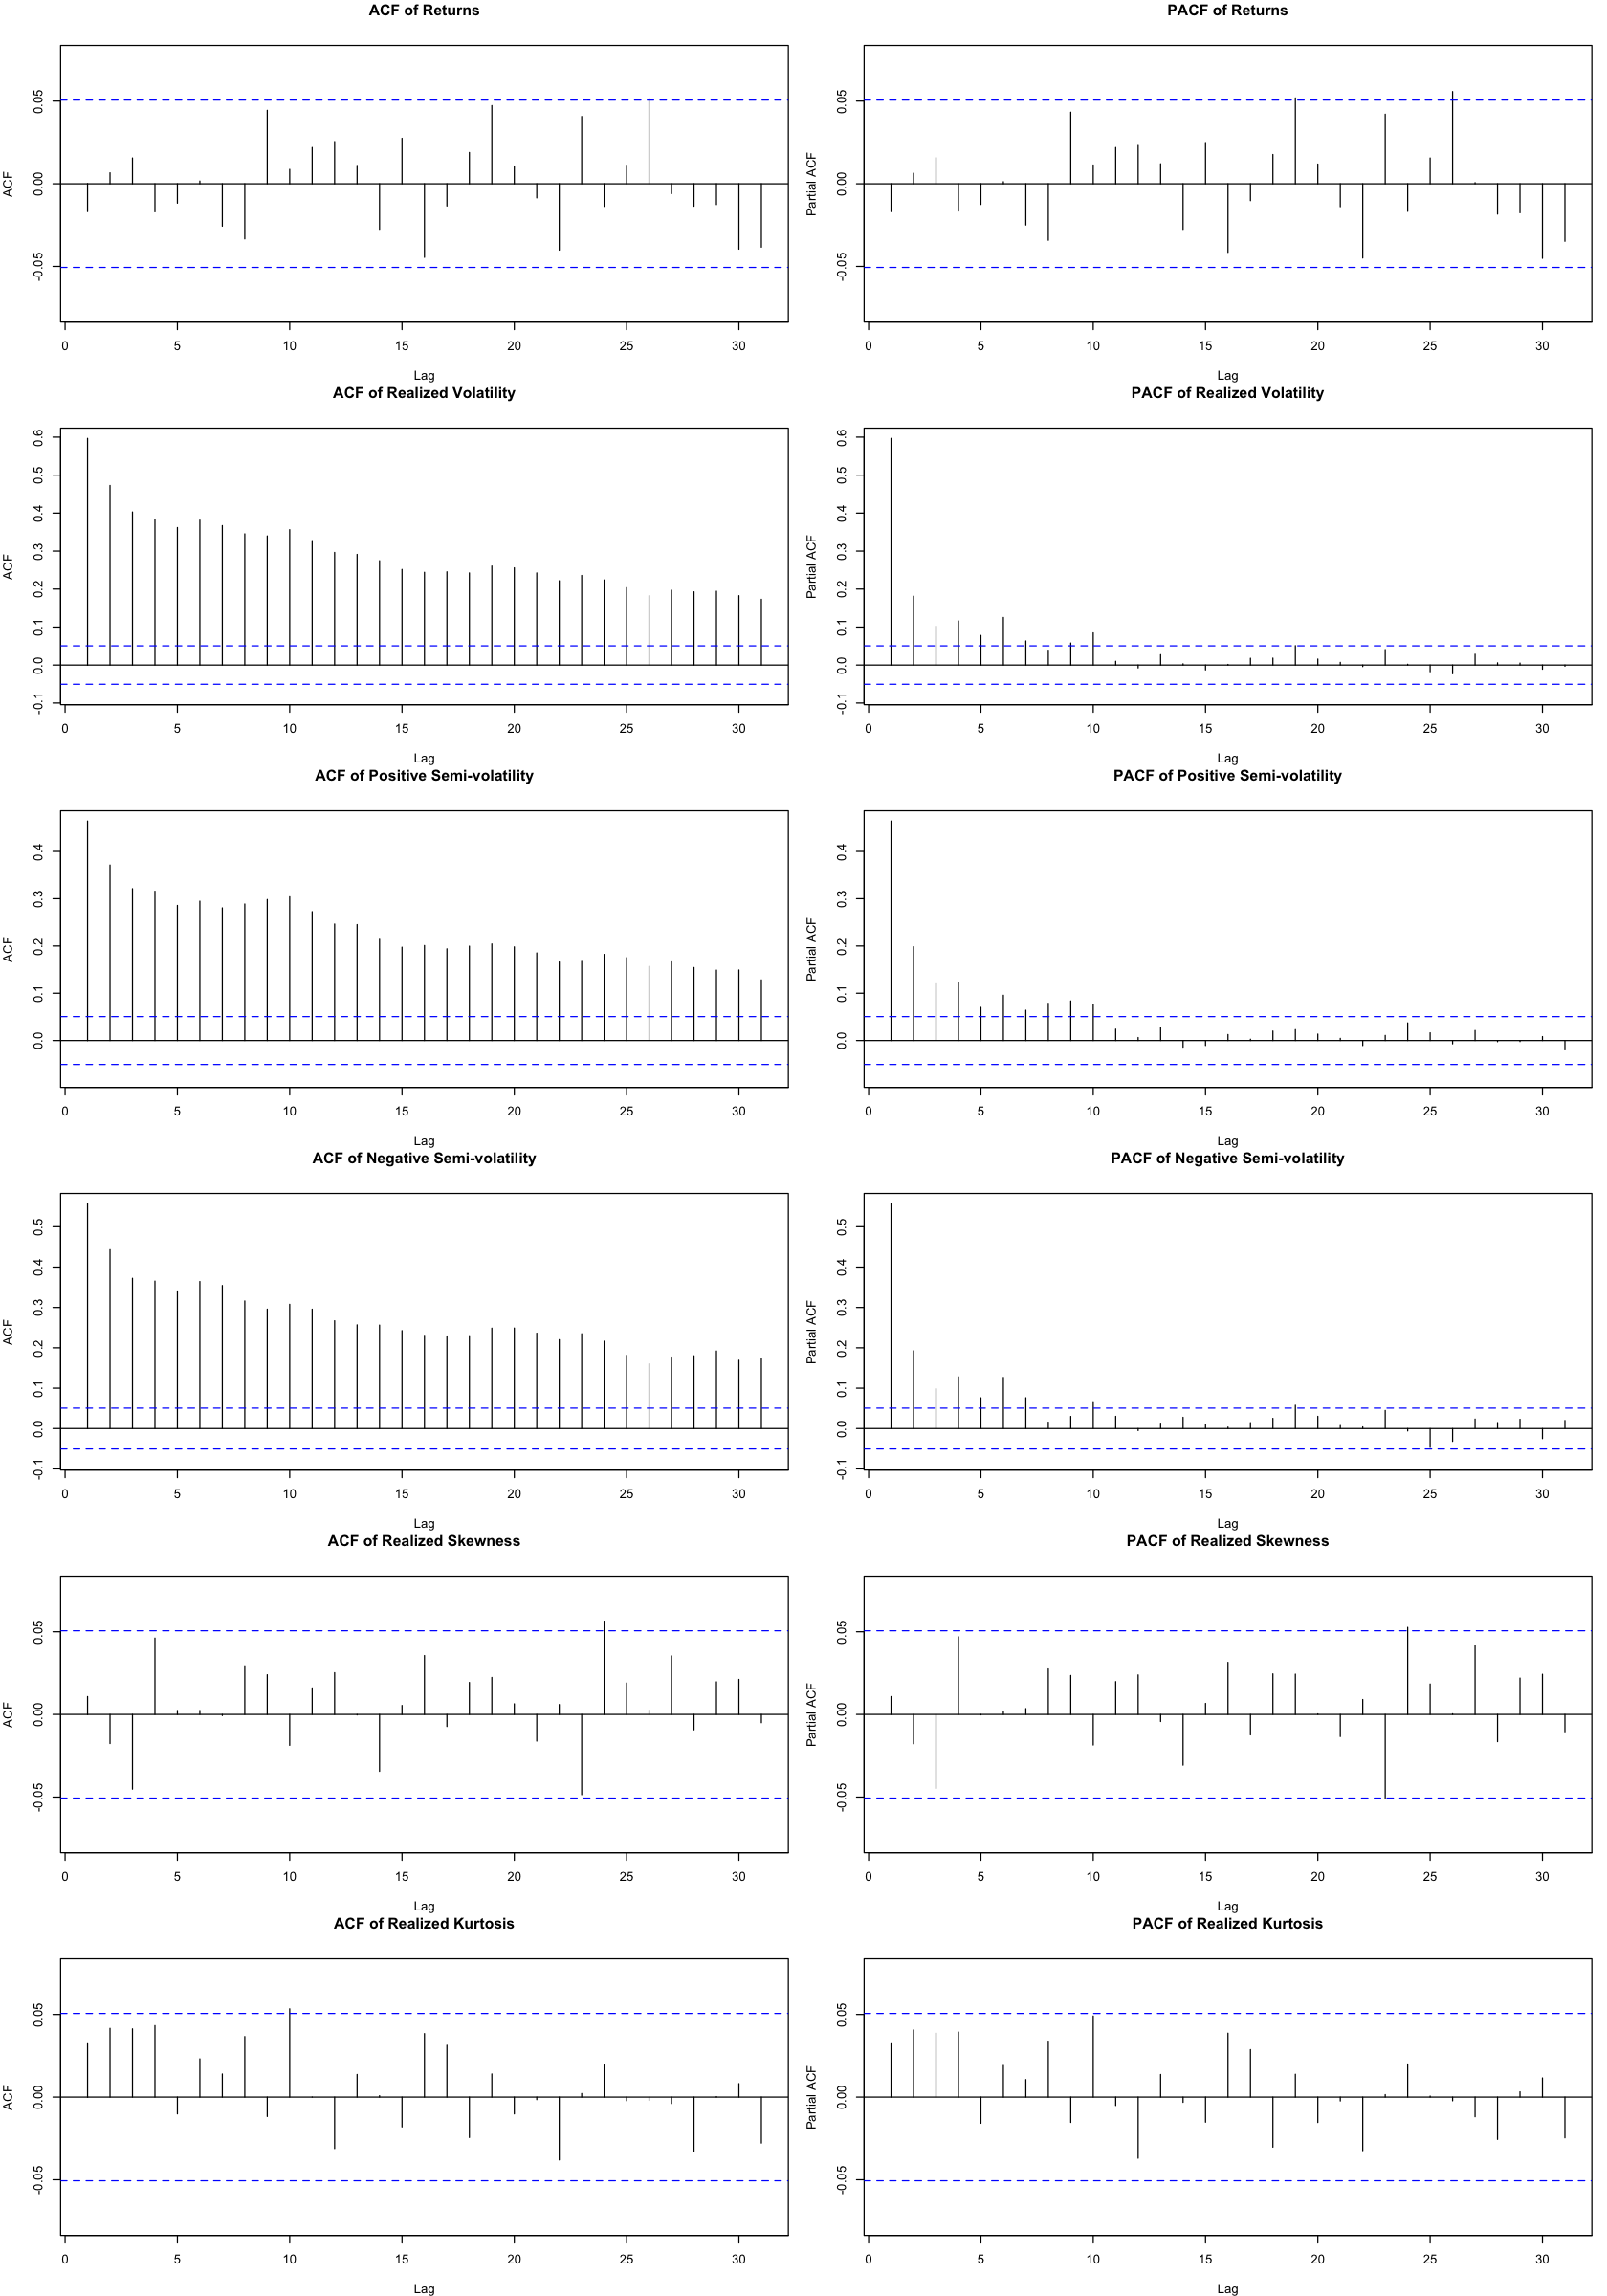

In [10]:
options(repr.plot.width = 14, repr.plot.height = 20)
par(mfrow = c(6, 2), mar = c(4, 4, 3, 1))

#ret
Acf(asset_data$ret, main = "ACF of Returns")
Pacf(asset_data$ret, main = "PACF of Returns")

#rv
Acf(asset_data$RV, main = "ACF of Realized Volatility")
Pacf(asset_data$RV, main = "PACF of Realized Volatility")

#rvp
Acf(asset_data$RV_p, main = "ACF of Positive Semi-volatility")
Pacf(asset_data$RV_p, main = "PACF of Positive Semi-volatility")

#rvn
Acf(asset_data$RV_n, main = "ACF of Negative Semi-volatility")
Pacf(asset_data$RV_n, main = "PACF of Negative Semi-volatility")
#rs
Acf(asset_data$RS, main = "ACF of Realized Skewness")
Pacf(asset_data$RS, main = "PACF of Realized Skewness")
#rk
Acf(asset_data$RK, main = "ACF of Realized Kurtosis")
Pacf(asset_data$RK, main = "PACF of Realized Kurtosis")


par(mfrow = c(1, 1))

The dataset covers 2010-01-05 to 2016-01-22, providing approximately 1,509 daily observations for AMAT. Each observation contains the daily log return and five realized measures computed from 5-minute intraday data.

### Returns (`ret`)

The time series plot shows daily log returns fluctuating around zero with no visible trend or drift throughout the entire sample. The distribution is roughly symmetric (mean ≈ 0.0002, median ≈ 0.0009), which we would expect for daily returns. The minimum and maximum correspond to single-day moves of -8.3% and +9.1% respectively, far larger than a normal distribution would imply, indicating that the returns have fatter tails than the normal distribution. Periods of larger swings are visually clustered — particularly around 2010–2011 and 2015–2016 — revealing the phenomenon of volatility clustering in equity returns.

The ACF and PACF of returns are almost entirely within the 95% confidence bands across all 32 lags, with only a few marginal crossings consistent with chance at the 5% level. This confirms that daily returns are serially uncorrelated, in line with the weak form of market efficiency: past returns carry no significant linear information about future returns.


### Realized Volatility (`RV`)

The time series of RV makes the volatility clustering visible in a much cleaner way than returns alone. RV oscillates around a baseline of approximately 0.014–0.015, with some sharp upward spikes — most prominent in early 2010 and again in 2015–2016. The distribution is clearly right-skewed: the mean (0.0152) exceeds the median (0.0143), and the maximum (0.0651) is more than 4× the median, reflecting the heavy right tail typical of realized volatility measures.

The ACF of RV starts at approximately 0.6 at lag 1 and decays very slowly, remaining statistically significant well beyond lag 30. This slow, gradual decay indicates high persistence, consistent with either long memory or near-unit-root dynamics. The PACF shows one dominant spike at lag 1 (~0.6), followed by a few smaller significant partial autocorrelations at lags 2–5, and then rapid decay toward zero. This combination — slowly decaying ACF with a sharp PACF cutoff — rules out a simple AR(1) and motivates richer models capable of capturing persistence across multiple horizons, most naturally the HAR model.

### Positive and Negative Semi-volatilities (`RV_p`, `RV_n`)

Both semi-volatility series closely mirror the shape of RV in the time series plot, which is expected by construction since $\text{RV}_t \approx \text{RV}^+_t + \text{RV}^-_t$. This is confirmed in the summary statistics: the means sum closely to the mean of RV ($0.0108 + 0.0106 \approx 0.0214$). On average, positive and negative intraday variation are nearly symmetric, though subtle asymmetries are visible during stress episodes — for instance, the early-2010 spike appears somewhat more pronounced in `RV_n`, suggesting a downside-driven event.

The ACF and PACF structures of both series are nearly identical to those of RV: slowly decaying ACF with significant autocorrelations through lag 30+, and a dominant PACF spike at lag 1 followed by rapid decay. This shared persistence structure is the motivation for the HAR-RS model, which decomposes RV into its positive and negative components to test whether intraday asymmetry carries incremental predictive content beyond total variation.

### Realized Skewness (`RS`)

In contrast to the volatility measures, RS fluctuates around zero with no visible persistence or clustering in the time series. The mean is slightly positive (0.10), indicating a marginal upward bias in intraday price moves on average, but the wide range (-3.77 to +4.87) and large IQR confirm high day-to-day variability.

The ACF and PACF of RS are almost entirely within the confidence bands — RS is close to white noise in its own dynamics. This is consistent with RS capturing the direction of intraday jumps, which is largely unpredictable from the past. Importantly, this does not make RS irrelevant as a predictor: in the HAR-RS and HAR-Moments models, today's skewness may still help forecast tomorrow's RV, even if past skewness cannot forecast future skewness.

### Realized Kurtosis (`RK`)

RK is always well above 3 throughout the sample — the mean is 5.71 and the median is 4.61 — confirming that intraday return distributions are fat-tailed every single day, not just during crises. Extreme values (up to 37.96) appear as isolated spikes in the time series, likely corresponding to earnings announcements or macro surprises, rather than as persistent regimes.

Like RS, the ACF and PACF of RK show no meaningful persistence — both are largely within the confidence bands across all lags. The day-to-day level of excess kurtosis is essentially unpredictable from its own past. As with RS, RK may nonetheless carry predictive value for future RV as a regressor in the HAR-Moments model, capturing the information content of extreme intraday moves for next-day volatility.

## In-Sample models

### data preparation

In [7]:
#rv lagged daily
RV_1 <- lag(asset_data$RV, 1)
#rolling weekly and monthly averages
RV_5 <- rollmean(RV_1, k = 5, fill = NA, align = "right")
RV_22 <- rollmean(RV_1, k = 22, fill = NA, align = "right")

In [8]:
#kurtosis and skeweness daily lags
RS_1 <- lag(asset_data$RS, 1)
RK_1 <- lag(asset_data$RK, 1)

In [9]:
#create dataset we will use for the regressions
har_data <- merge(asset_data$RV, RV_1, RV_5, RV_22, RS_1, RK_1)
colnames(har_data) <- c("RV", "RV_1", "RV_5", "RV_22", "RS_1", "RK_1")
har_data <- na.omit(har_data)
head(har_data)

                   RV       RV_1       RV_5      RV_22        RS_1     RK_1
2010-02-05 0.01763226 0.01524947 0.01469028 0.01320064 -1.12125287 3.358569
2010-02-08 0.01455525 0.01763226 0.01531788 0.01350168 -0.49338831 3.403187
2010-02-09 0.01284877 0.01455525 0.01472184 0.01365406  1.15215080 4.622531
2010-02-10 0.01186413 0.01284877 0.01490656 0.01370632 -0.03282452 3.489046
2010-02-11 0.01731071 0.01186413 0.01442998 0.01382000  0.04536075 2.332321
2010-02-12 0.01342206 0.01731071 0.01484222 0.01409567  1.74570619 6.696822

### Models

In [10]:
fit_ar1 <- lm(RV ~ RV_1, data = har_data)
summary(fit_ar1)


Call:
lm(formula = RV ~ RV_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.019555 -0.002147 -0.000728  0.001081  0.045273 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0057147  0.0002665   21.45   <2e-16 ***
RV_1        0.4547394  0.0231955   19.61   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004203 on 1476 degrees of freedom
Multiple R-squared:  0.2066,	Adjusted R-squared:  0.2061 
F-statistic: 384.3 on 1 and 1476 DF,  p-value: < 2.2e-16


In [11]:
fit_har <- lm(RV ~ RV_1 + RV_5 + RV_22, data = har_data)
summary(fit_har)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012629 -0.002062 -0.000618  0.001081  0.045830 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0018621  0.0004311   4.319 1.67e-05 ***
RV_1        0.2298062  0.0306640   7.494 1.14e-13 ***
RV_5        0.2777390  0.0572872   4.848 1.38e-06 ***
RV_22       0.3155588  0.0612917   5.148 2.98e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004013 on 1474 degrees of freedom
Multiple R-squared:  0.2775,	Adjusted R-squared:  0.276 
F-statistic: 188.7 on 3 and 1474 DF,  p-value: < 2.2e-16


In [12]:
fit_har_rs <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)
summary(fit_har_rs)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012174 -0.002054 -0.000594  0.001057  0.045952 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.828e-03  4.311e-04   4.240 2.38e-05 ***
RV_1         2.376e-01  3.091e-02   7.686 2.75e-14 ***
RV_5         2.743e-01  5.726e-02   4.790 1.83e-06 ***
RV_22        3.153e-01  6.124e-02   5.149 2.97e-07 ***
RS_1        -1.639e-04  8.625e-05  -1.900   0.0577 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00401 on 1473 degrees of freedom
Multiple R-squared:  0.2793,	Adjusted R-squared:  0.2773 
F-statistic: 142.7 on 4 and 1473 DF,  p-value: < 2.2e-16


In [13]:
fit_har_rs_rk <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)
summary(fit_har_rs_rk)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.011862 -0.001980 -0.000619  0.001037  0.045951 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.570e-03  4.508e-04   5.701 1.43e-08 ***
RV_1         3.149e-01  3.409e-02   9.238  < 2e-16 ***
RV_5         2.441e-01  5.707e-02   4.277 2.02e-05 ***
RV_22        2.696e-01  6.135e-02   4.394 1.19e-05 ***
RS_1        -1.220e-04  8.589e-05  -1.420    0.156    
RK_1        -1.144e-04  2.211e-05  -5.177 2.57e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003975 on 1472 degrees of freedom
Multiple R-squared:  0.2922,	Adjusted R-squared:  0.2898 
F-statistic: 121.5 on 5 and 1472 DF,  p-value: < 2.2e-16


In [14]:
spec_garch <- ugarchspec(
  mean.model = list(armaOrder = c(1, 1), include.mean = TRUE),
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)
fit_garch <- ugarchfit(spec = spec_garch, data = asset_data$ret)
show(fit_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000530    0.000226   2.3437 0.019094
ar1     0.682422    0.107282   6.3610 0.000000
ma1    -0.780003    0.092411  -8.4406 0.000000
omega   0.000005    0.000001   5.3958 0.000000
alpha1  0.054719    0.006214   8.8053 0.000000
beta1   0.920647    0.008867 103.8278 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000530    0.000254   2.0854 0.037029
ar1     0.682422    0.139481   4.8926 0.000001
ma1    -0.780003    0.117267  -6.6515 0.000000
omega   0.000005    0.000002   2.3237 0.020143
alpha1  0.054719    0.012434   4.4009 0.000011
beta1   0.920647    0.010465  87.9730 0.000000

LogLike

In [15]:
spec_real <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "realGARCH", garchOrder = c(1, 1))
)
# Note: hybrid solver is often more robust for Realized GARCH
fit_garch_real <- ugarchfit(spec = spec_real, data = asset_data$ret, 
                           solver = "hybrid", realizedVol = asset_data$RV)
show(fit_garch_real)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000398    0.000295   1.3465 0.178127
omega   0.694118    0.286940   2.4190 0.015561
alpha1  1.000000    0.116451   8.5873 0.000000
beta1   0.551884    0.044378  12.4359 0.000000
eta11  -0.037812    0.007205  -5.2477 0.000000
eta21   0.027531    0.003163   8.7030 0.000000
delta   0.343272    0.023601  14.5447 0.000000
lambda  0.264994    0.004870  54.4180 0.000000
xi     -1.612659    0.205991  -7.8288 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000398    0.000259   1.5355 0.124659
omega   0.694118    0.350473   1.9805 0.047645
alpha1  1.000000    0.210624   4.7478 0.000002
beta1

In [16]:
fitted_ar1 <- xts(fitted(fit_ar1), order.by = index(har_data))
fitted_har <- xts(fitted(fit_har), order.by = index(har_data))
fitted_har_rs <- xts(fitted(fit_har_rs), order.by = index(har_data))
fitted_har_rs_rk <- xts(fitted(fit_har_rs_rk), order.by = index(har_data))
fitted_garch <- xts(sigma(fit_garch), order.by = index(asset_data$ret))
fitted_garch_real <- xts(sigma(fit_garch_real), order.by = index(asset_data$ret))

In [17]:
fit_comparison <- merge(asset_data$RV, fitted_ar1, fitted_har, fitted_har_rs, fitted_har_rs_rk, fitted_garch, fitted_garch_real)
colnames(fit_comparison) <- c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit", "GARCH_Fit", "RealGARCH_Fit")

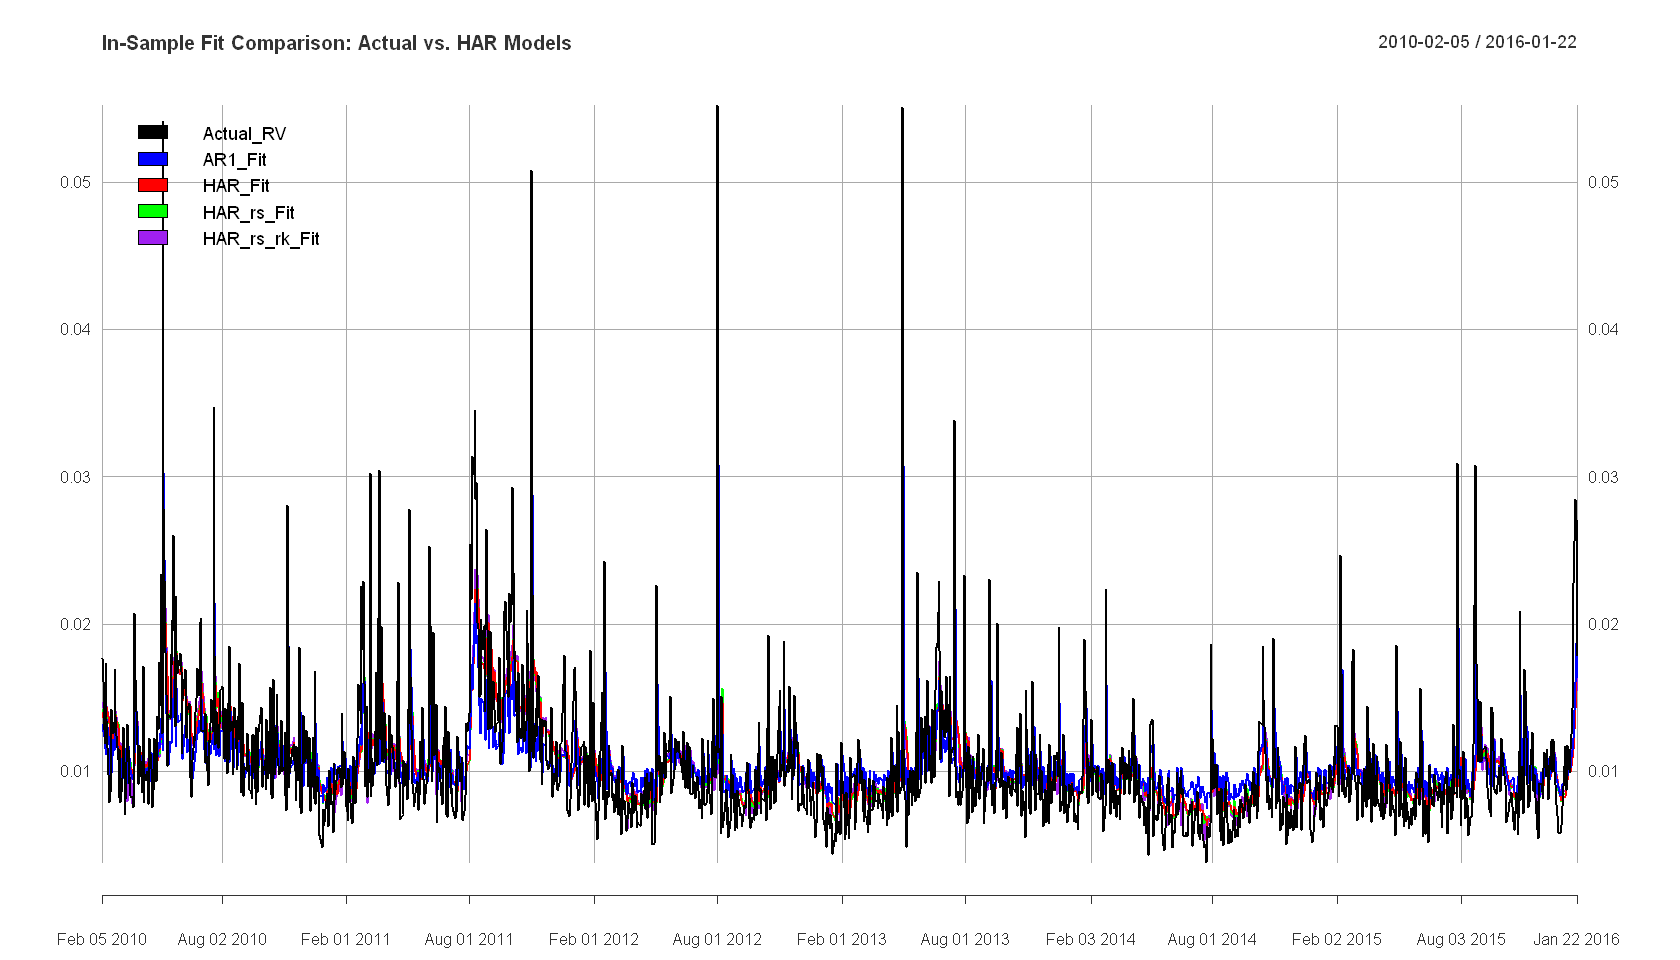

In [18]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models",
         legend.loc = "topleft")

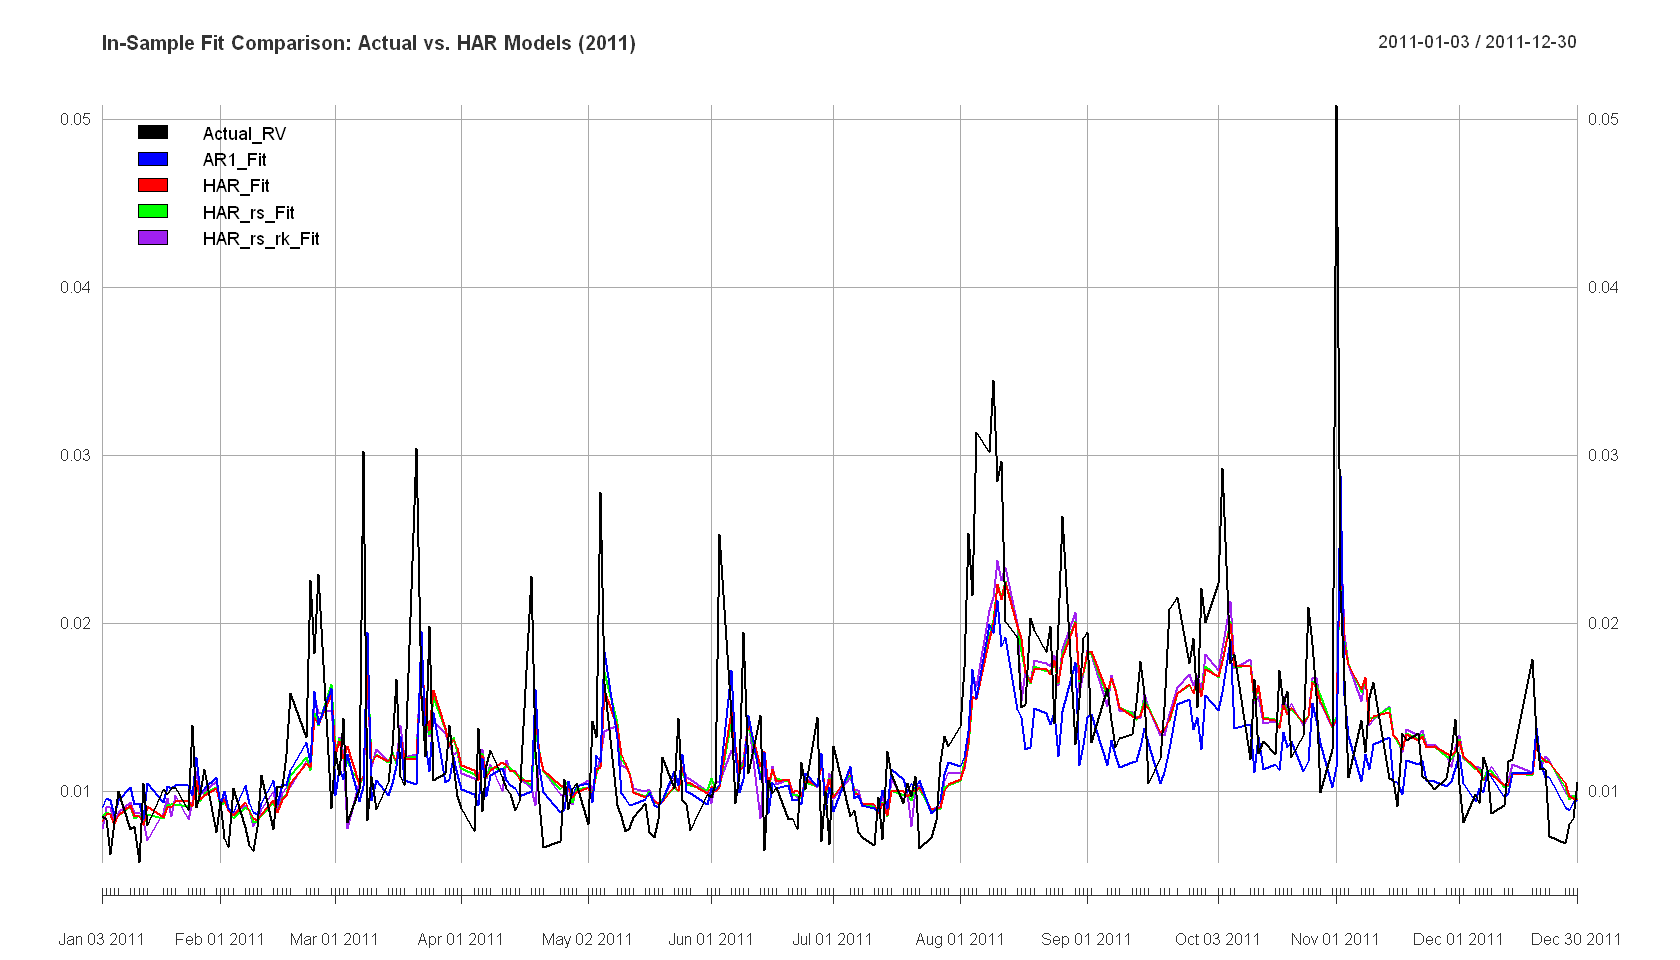

In [19]:
options(repr.plot.width = 14, repr.plot.height = 8)

#zoom in on 2011 for example
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, 
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (2011)",
         legend.loc = "topleft")

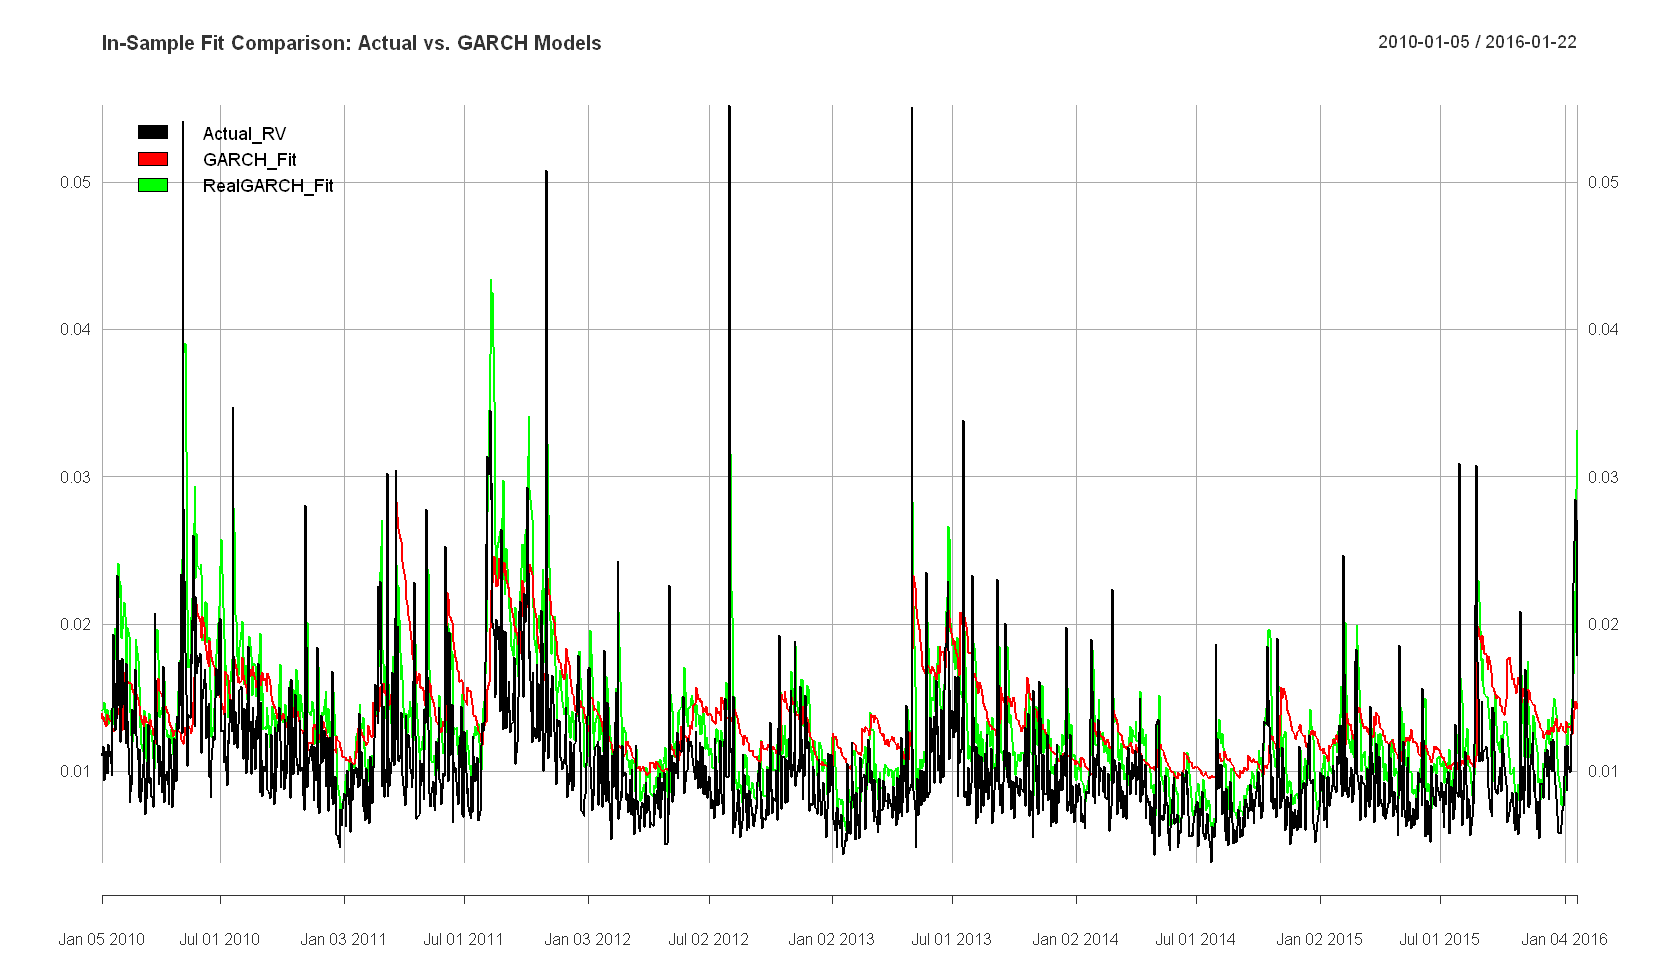

In [20]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

## Forectasts

In [21]:
window_len <- 750
n_obs <- nrow(har_data)
out_sample_len <- n_obs - window_len

In [22]:
fcst_ar1_roll <- numeric(out_sample_len)
fcst_har_roll <- numeric(out_sample_len)
fcst_har_rs_roll <- numeric(out_sample_len)
fcst_har_rs_rk_roll <- numeric(out_sample_len)

fcst_ar1_exp <- numeric(out_sample_len)
fcst_har_exp <- numeric(out_sample_len)
fcst_har_rs_exp <- numeric(out_sample_len)
fcst_har_rs_rk_exp <- numeric(out_sample_len)

# Actual values for the out-of-sample period to compare against
actual_out_sample <- har_data$RV[(window_len + 1):n_obs]

In [23]:
for (i in 1:out_sample_len) {
  
  # Rolling Window 
  train_data_roll <- har_data[i:(window_len + i - 1), ]
  
  # Expanding Window 
  train_data_exp <- har_data[1:(window_len + i - 1), ]
  
  # The row of data we are using to predict tomorrow's RV
  test_data <- har_data[(window_len + i), ]
  
  # --- ROLLING WINDOW FITS & FORECASTS ---
  fit_ar1_roll <- lm(RV ~ RV_1, data = train_data_roll)
  fit_har_roll <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_roll)
  fit_har_rs_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_roll)
  fit_har_rs_rk_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_roll)
    
  fcst_ar1_roll[i] <- predict(fit_ar1_roll, newdata = test_data)
  fcst_har_roll[i] <- predict(fit_har_roll, newdata = test_data)
  fcst_har_rs_roll[i] <- predict(fit_har_rs_roll, newdata = test_data)  
  fcst_har_rs_rk_roll[i] <- predict(fit_har_rs_rk_roll, newdata = test_data) 
    
  # --- EXPANDING WINDOW FITS & FORECASTS ---
  fit_ar1_exp <- lm(RV ~ RV_1, data = train_data_exp)
  fit_har_exp <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_exp)
  fit_har_rs_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_exp)
  fit_har_rs_rk_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_exp)
    
  fcst_ar1_exp[i] <- predict(fit_ar1_exp, newdata = test_data)
  fcst_har_exp[i] <- predict(fit_har_exp, newdata = test_data)
  fcst_har_rs_exp[i] <- predict(fit_har_rs_exp, newdata = test_data)  
  fcst_har_rs_rk_exp[i] <- predict(fit_har_rs_rk_exp, newdata = test_data)   
}

to dalsi nefunguje

In [ ]:
#garch_roll <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "moving")
#garch_exp  <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "recursive")
#
#fcst_garch_roll <- garch_roll@forecast$density[,"Sigma"]
#fcst_garch_exp  <- garch_exp@forecast$density[,"Sigma"]
#
# Realized GARCH (passing the realizedVol argument), REFIT 5 or 1? recalculate for every day or week? mostly bcs of computation
#realGARCH_roll <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "moving", solver = "hybrid")
#realGARCH_exp  <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "recursive", solver = "hybrid")
#
#fcst_realGARCH_roll <- realGARCH_roll@forecast$density[,"Sigma"]
#fcst_realGARCH_exp  <- realGARCH_exp@forecast$density[,"Sigma"]

In [24]:
# Helper function to calculate MSE and MAE
calc_loss <- function(actual, forecast) {
  error <- actual - forecast
  mse <- mean(error^2, na.rm = TRUE)
  mae <- mean(abs(error), na.rm = TRUE)
  return(c(MSE = mse, MAE = mae))
}

In [27]:
results_matrix <- rbind(
  calc_loss(actual_out_sample, fcst_ar1_roll),
  calc_loss(actual_out_sample, fcst_har_roll),
  calc_loss(actual_out_sample, fcst_har_rs_roll),
  calc_loss(actual_out_sample, fcst_har_rs_rk_roll),
  calc_loss(actual_out_sample, fcst_ar1_exp),
  calc_loss(actual_out_sample, fcst_har_exp),
  calc_loss(actual_out_sample, fcst_har_rs_exp),
  calc_loss(actual_out_sample, fcst_har_rs_rk_exp)
)

rownames(results_matrix) <- c(
  "AR1 (Roll)", "HAR (Roll)", "HAR-RS (Roll)", "HAR-RS-RK (Roll)",
  "AR1 (Exp)", "HAR (Exp)", "HAR-RS (Exp)", "HAR-RS-RK (Exp)"
)

In [28]:
cat("--- OUT-OF-SAMPLE FORECAST EVALUATION ---\n")
print(round(results_matrix, 7))

--- OUT-OF-SAMPLE FORECAST EVALUATION ---
                      MSE       MAE
AR1 (Roll)       1.36e-05 0.0022818
HAR (Roll)       1.29e-05 0.0021347
HAR-RS (Roll)    1.29e-05 0.0021288
HAR-RS-RK (Roll) 1.28e-05 0.0021174
AR1 (Exp)        1.39e-05 0.0024097
HAR (Exp)        1.28e-05 0.0021482
HAR-RS (Exp)     1.28e-05 0.0021468
HAR-RS-RK (Exp)  1.27e-05 0.0021336


In [29]:
err_ar1       <- actual_out_sample - fcst_ar1_roll
err_har       <- actual_out_sample - fcst_har_roll
err_har_rs    <- actual_out_sample - fcst_har_rs_roll
err_har_rs_rk <- actual_out_sample - fcst_har_rs_rk_roll

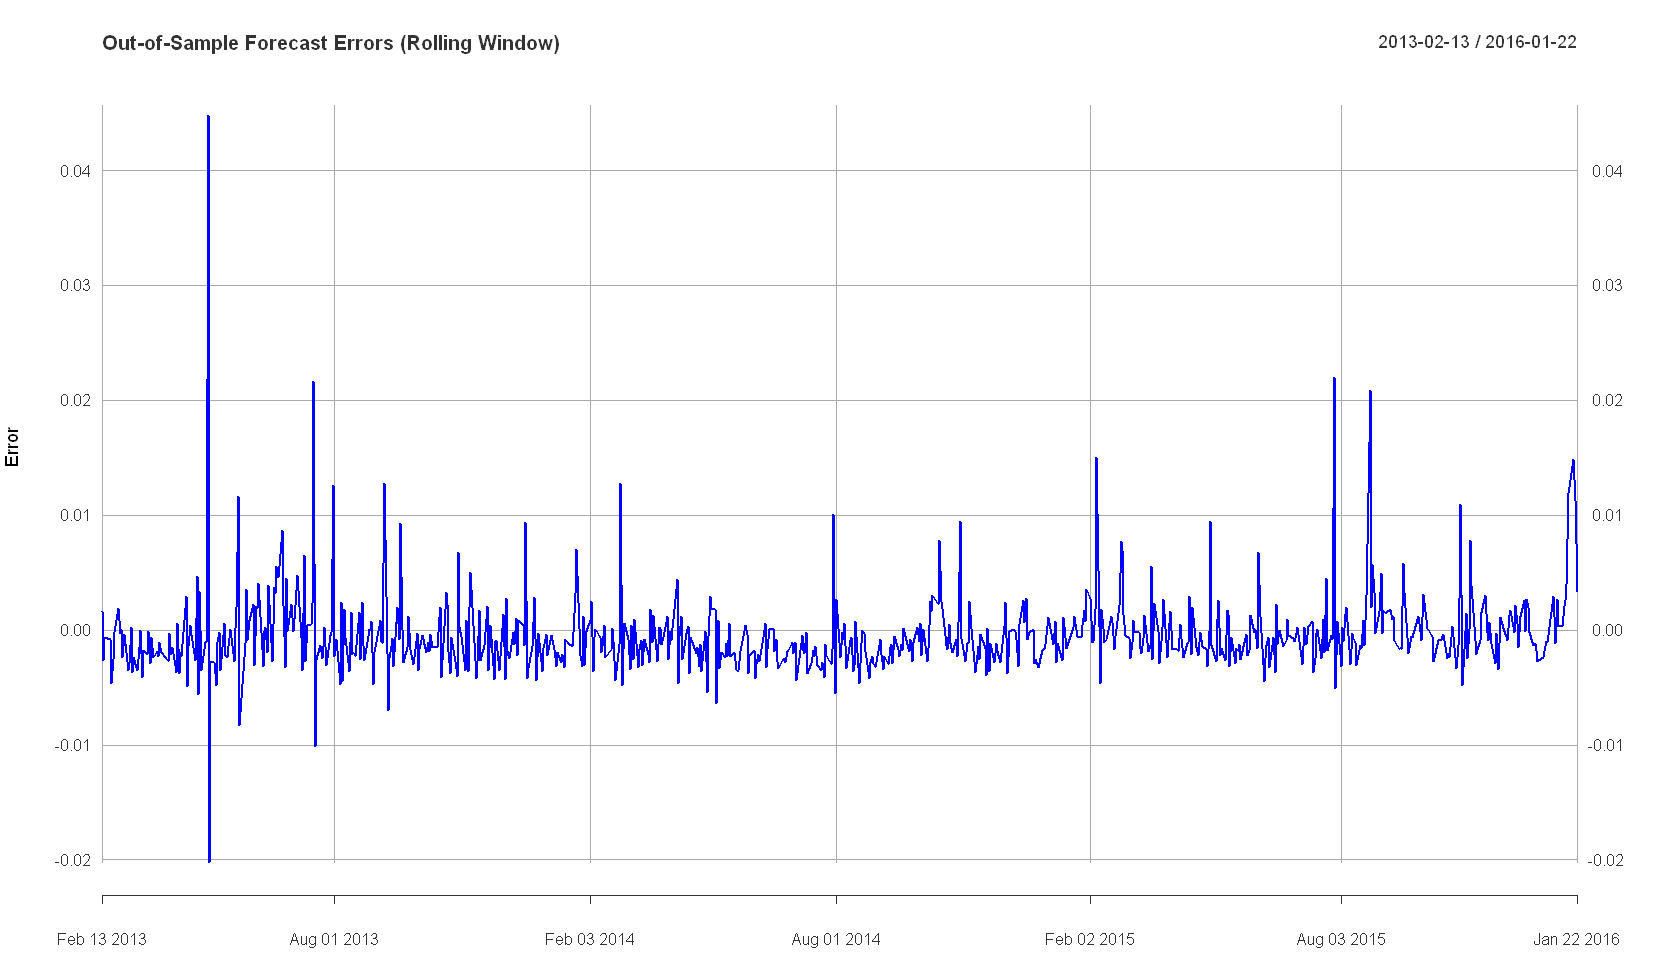

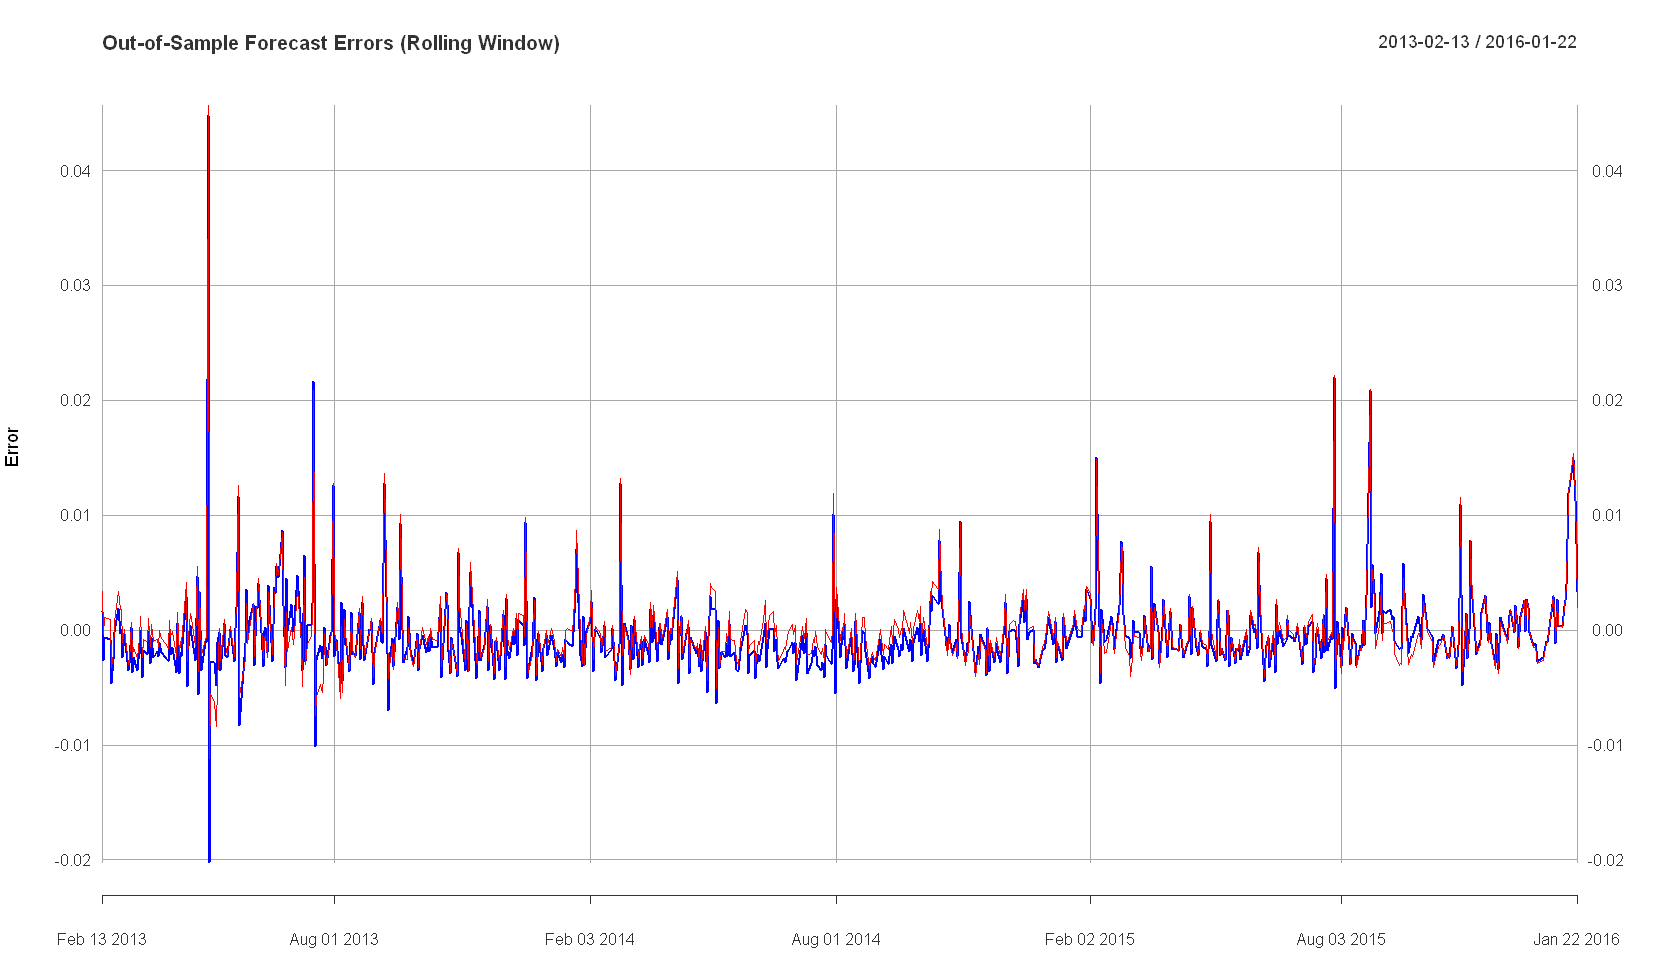

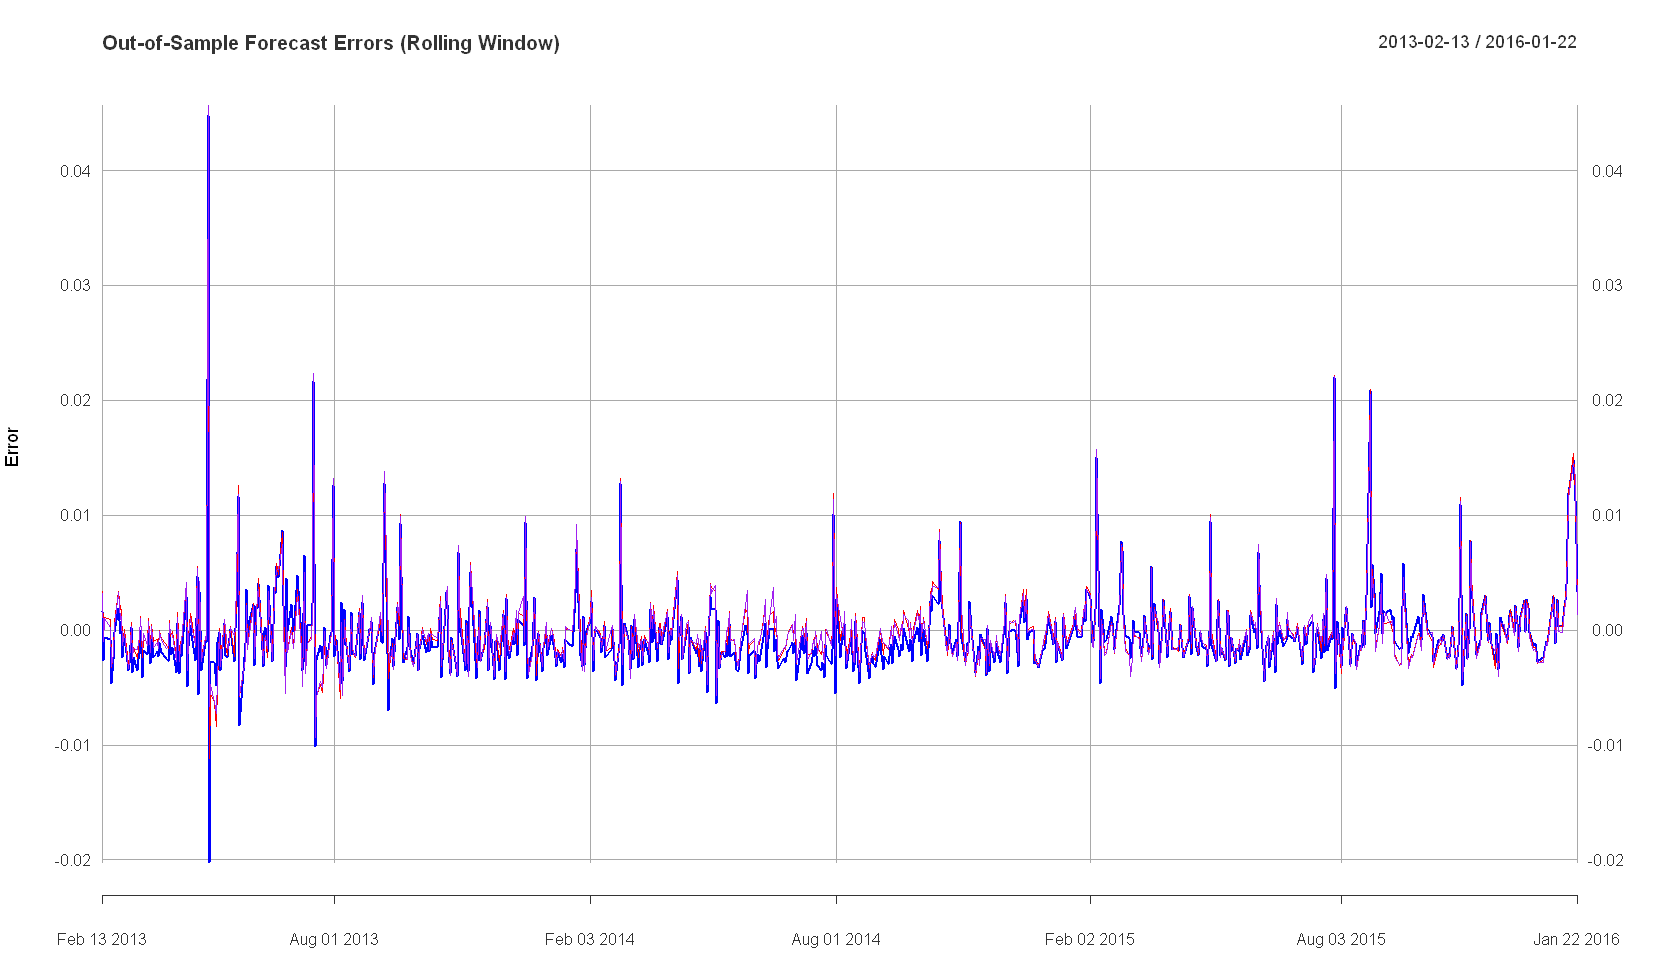

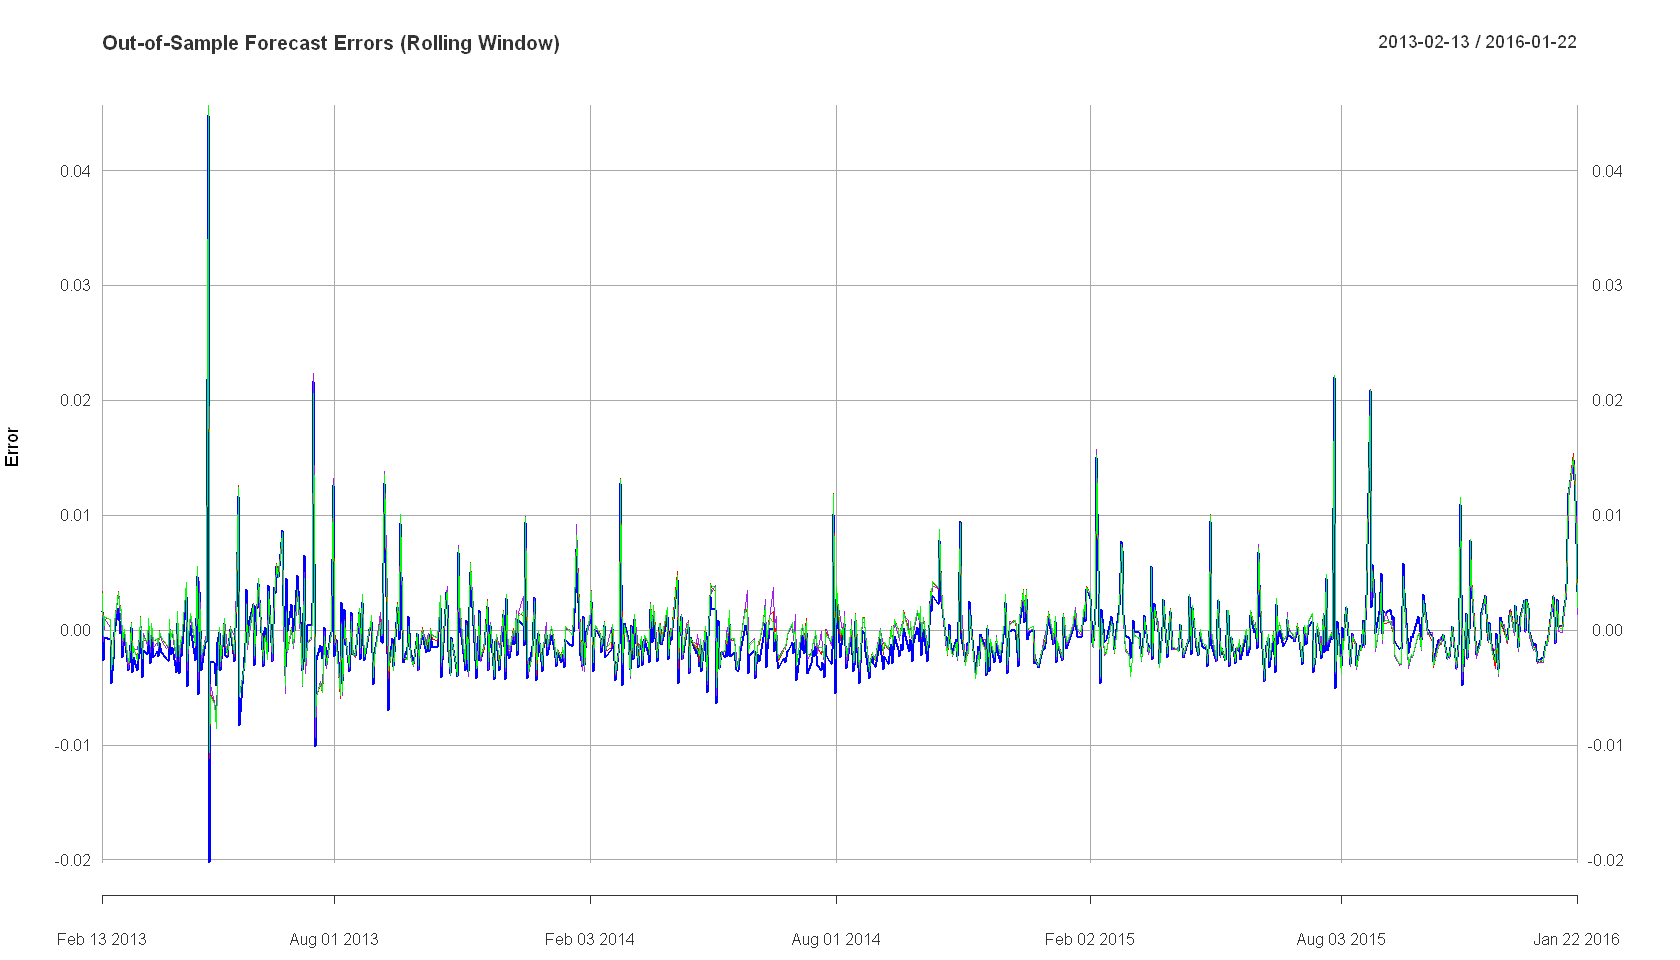

In [31]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot(err_ar1, type = "l", col = "blue", ylim = range(c(err_ar1, err_har), na.rm=TRUE),
     main = "Out-of-Sample Forecast Errors (Rolling Window)", ylab = "Error", xlab = "Time")
lines(err_har, col = "red")
lines(err_har_rs_rk, col = "purple")
lines(err_har_rs, col = "green")
legend("topleft", legend = c("AR1", "HAR", "HAR-RS-RK", "HAR-RS"), 
       col = c("blue", "red", "purple", "green"), lty = 1)

In [32]:
# 1. Diebold-Mariano Test (Comparing models against the baseline HAR model)
cat("\n--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---\n")
print(dm.test(err_har, err_ar1, alternative = "two.sided", power = 2))
print(dm.test(err_har, err_har_rs_rk, alternative = "two.sided", power = 2))
print(dm.test(err_har, err_har_rs, alternative = "two.sided", power = 2))


--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---

	Diebold-Mariano Test

data:  err_harerr_ar1
DM = -1.492, Forecast horizon = 1, Loss function power = 2, p-value =
0.1361
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_harerr_har_rs_rk
DM = 0.53994, Forecast horizon = 1, Loss function power = 2, p-value =
0.5894
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_harerr_har_rs
DM = 1.1282, Forecast horizon = 1, Loss function power = 2, p-value =
0.2596
alternative hypothesis: two.sided

